# Olist E-Commerce Analysis

## Business context
An analyst at Olist wants to understand two things: (1) where revenue is 
concentrated geographically and what drives it, and (2) how delivery performance 
affects customer satisfaction. This analysis identifies which states, sellers, 
or categories warrant operational focus and what specifically improves the 
customer experience.

## Questions
1. Where is revenue concentrated, and what does the top tier look like?
2. Does faster delivery actually correlate with better reviews?

## Headline findings
- **Revenue is hyper-concentrated geographically.** São Paulo (SP) alone 
  generates BRL 5.77M, more than the next three states combined. Together with 
  Rio de Janeiro (RJ) and Minas Gerais (MG), the top three states account for 
  roughly 77% of revenue across the top 10.
- **Concentration is driven by volume, not basket size.** São Paulo has the 
  *lowest* average order value (BRL 142) of the top 10 states. Smaller states 
  like Bahia (BRL 182) have higher AOVs but far lower order counts.
- **Delivery time is a major driver of satisfaction.** The Pearson correlation 
  between delivery time and review score is -0.334 across 95,824 orders. Average 
  reviews fall from 4.41 (0-7 days) to 2.17 (31-60 days).
- **Satisfaction has a sharp cliff at 21-30 days.** Reviews stay above 4.0 up 
  to 21 days, then fall sharply. Past 30 days, 1-star reviews become the 
  majority. Operationally, this means preventing slippage past 21 days matters 
  more than shaving days off already-fast deliveries.

## Tools
- Python 3.12, pandas, numpy
- matplotlib, seaborn
- scipy (correlation testing)

## 1. Data loading
We load all relevant CSVs and inspect their basic shape.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling (applied once for the whole notebook)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

orders = pd.read_csv('data/olist_orders_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')

print("orders:", orders.shape)
print("customers:", customers.shape)
print("order_items:", order_items.shape)
print("products:", products.shape)
print("reviews:", reviews.shape)

orders: (99441, 8)
customers: (99441, 5)
order_items: (112650, 7)
products: (32951, 9)
reviews: (99224, 7)


## 2. Initial inspection
For each table, we check the shape, columns, and total null count before merging anything.

In [24]:
# Quick overview of all five tables
tables = {
    'orders': orders,
    'customers': customers,
    'order_items': order_items,
    'products': products,
    'reviews': reviews,
}

for name, table in tables.items():
    print(f"--- {name} ---")
    print(f"shape:       {table.shape}")
    print(f"columns:     {table.columns.tolist()}")
    print(f"total nulls: {table.isnull().sum().sum()}")
    print()

--- orders ---
shape:       (99441, 8)
columns:     ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
total nulls: 4908

--- customers ---
shape:       (99441, 5)
columns:     ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
total nulls: 0

--- order_items ---
shape:       (112650, 7)
columns:     ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
total nulls: 0

--- products ---
shape:       (32951, 9)
columns:     ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
total nulls: 2448

--- reviews ---
shape:       (99224, 7)
columns:     ['review_id', 'order_id', 'review_score', 'review_comment_title

## 3. Data cleaning

We parse the date columns to datetime so we can compute delivery times later, 
then join `order_items`, `orders`, and `customers` into a state-level 
item-revenue dataframe.

In [25]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


To compute revenue by state, we need:
- `order_items.price` + `order_items.freight_value` (per item)
- joined to `orders` on `order_id`
- joined to `customers` on `customer_id` (to get state)

In [26]:
# Start with order_items (one row per item) and enrich with state + status
revenue_items = order_items.merge(
    orders[['order_id', 'customer_id', 'order_status']],
    on='order_id', how='left'
)

# Add customer state
revenue_items = revenue_items.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id', how='left'
)

# Filter to delivered orders only (incomplete orders shouldn't count for revenue)
revenue_items = revenue_items[revenue_items['order_status'] == 'delivered']

# Compute total revenue per item (price + shipping)
revenue_items['item_revenue'] = revenue_items['price'] + revenue_items['freight_value']

print(revenue_items.shape)
revenue_items.head()

(110197, 11)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,customer_state,item_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,RJ,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,SP,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,MG,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,SP,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,SP,218.04


In [27]:
revenue_by_state = revenue_items.groupby('customer_state').agg(
    total_revenue=('item_revenue', 'sum'),
    order_count=('order_id', 'nunique'),
    item_count=('order_id', 'count')
).reset_index()

revenue_by_state['avg_order_value'] = revenue_by_state['total_revenue'] / revenue_by_state['order_count']
revenue_by_state = revenue_by_state.sort_values('total_revenue', ascending=False)

revenue_by_state.head(10)

,customer_state,total_revenue,order_count,item_count,avg_order_value
25,SP,5769703.15,40501,46448,142.458289
18,RJ,2055401.57,12350,14143,166.429277
10,MG,1818891.67,11354,12916,160.198315
22,RS,861472.79,5345,6134,161.173581
17,PR,781708.80,4923,5649,158.787081
23,SC,595127.78,3546,4097,167.830733
4,BA,591137.81,3256,3683,181.553381
6,DF,346123.35,2080,2355,166.405457
8,GO,334212.35,1957,2277,170.777900
7,ES,317657.93,1995,2225,159.227033


## 4. Question 1: Revenue concentration

This section answers the first business question: where does revenue concentrate 
geographically, and what does the top tier of the market look like? We rank states 
by total delivered-order revenue, compare average order value across the top 10, 
then drill into product categories within the top three states.

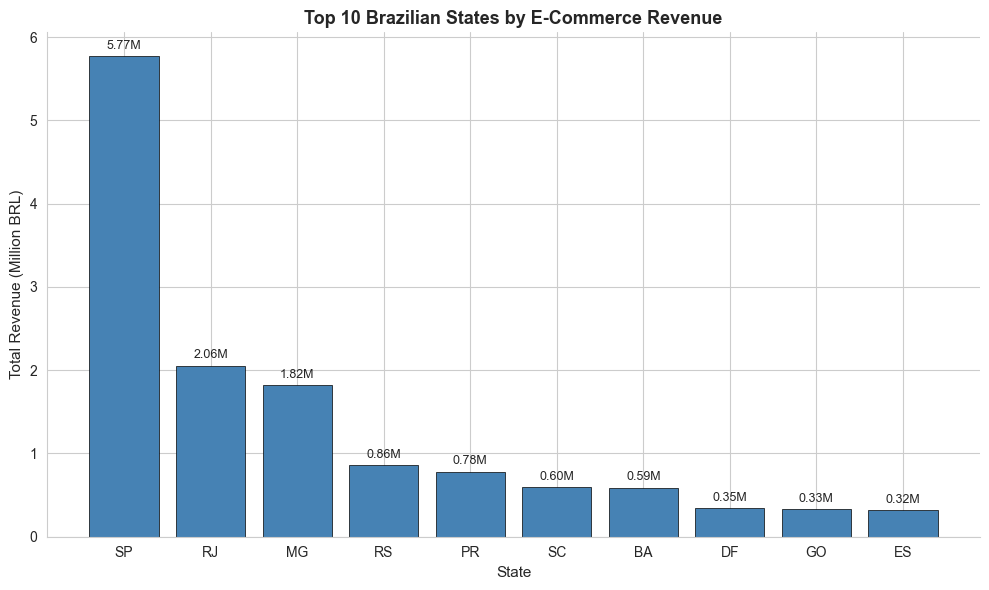

In [28]:
# Take top 10 states by total revenue
top_10 = revenue_by_state.head(10)

# Create the chart
fig, ax = plt.subplots()
bars = ax.bar(top_10['customer_state'], top_10['total_revenue'] / 1_000_000,
              color='steelblue', edgecolor='black', linewidth=0.5)

# Labels and title
ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Total Revenue (Million BRL)', fontsize=11)
ax.set_title('Top 10 Brazilian States by E-Commerce Revenue', fontsize=13, fontweight='bold')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.05,
            f'{height:.2f}M', ha='center', va='bottom', fontsize=9)

# Clean up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Average order value by state
The top revenue state (SP) has the lowest average order value in the top 10. 
Revenue concentration is driven by order volume, not basket size.

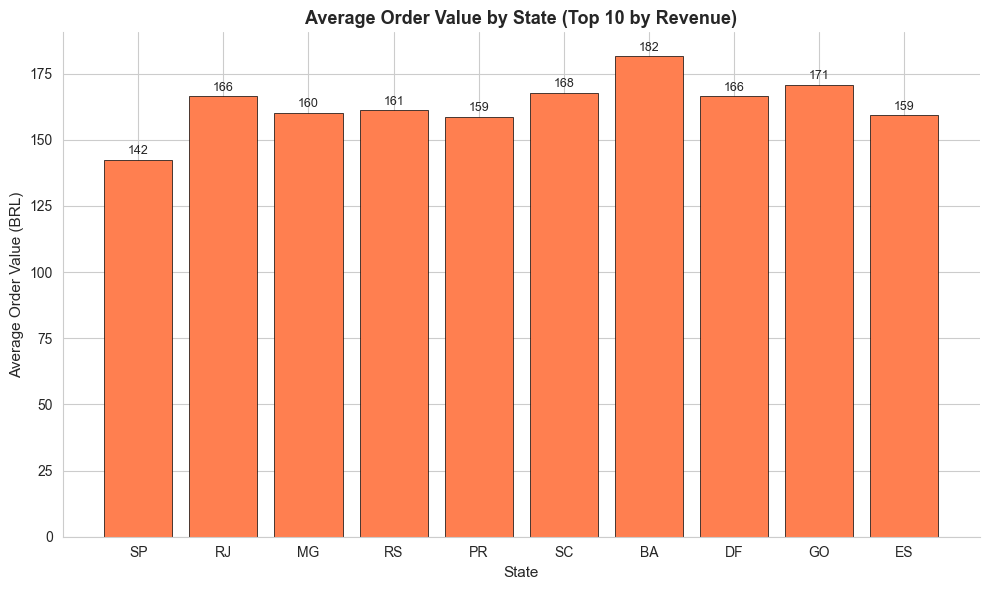

In [29]:
# Same top 10, different metric
fig, ax = plt.subplots()
bars = ax.bar(top_10['customer_state'], top_10['avg_order_value'],
              color='coral', edgecolor='black', linewidth=0.5)

ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Average Order Value (BRL)', fontsize=11)
ax.set_title('Average Order Value by State (Top 10 by Revenue)', fontsize=13, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1,
            f'{height:.0f}', ha='center', va='bottom', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Findings: State-level revenue

**Revenue is heavily concentrated in the southeastern states.** São Paulo (SP) 
alone generates BRL 5.77M in revenue from delivered orders, more than the next 
three states combined. The top three states (SP, RJ, MG) account for roughly 
77% of revenue across the top 10 states.

**Concentration is driven by order volume, not basket size.** Despite 
generating the most revenue, São Paulo has the *lowest* average order value 
(BRL 142) among the top 10 states. States like Bahia (BRL 182), Goiás (BRL 171), 
and Santa Catarina (BRL 168) have notably higher AOVs but a tiny fraction of 
SP's order volume.

**Business implication.** Operations and marketing investment should be 
weighted toward the southeastern volume markets (SP, RJ, MG), but pricing 
or upsell strategy could be tested in the higher-AOV markets where customers 
already place larger orders. The volume markets are unlikely to respond to 
basket-size optimization in the same way.

### Caveats
- Analysis filters to delivered orders only; cancelled and incomplete orders are excluded.
- "Order count" here is the number of unique orders. Revenue includes both product price and freight.
- This analysis does not yet break down which categories drive revenue within top states; that follows in the next section.

### 4.1 Revenue by category within top states

Now we drill into where revenue concentrates *within* the top states. 
São Paulo dominates total revenue. Which categories drive that dominance?

In [30]:
# Add product category to revenue_items
revenue_items = revenue_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

print("After category merge:", revenue_items.shape)
print("Nulls in category:", revenue_items['product_category_name'].isnull().sum())
revenue_items[['order_id', 'customer_state', 'product_category_name', 'item_revenue']].head()

After category merge: (110197, 12)
Nulls in category: 1537


,order_id,customer_state,product_category_name,item_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,RJ,cool_stuff,72.19
1,00018f77f2f0320c557190d7a144bdd3,SP,pet_shop,259.83
2,000229ec398224ef6ca0657da4fc703e,MG,moveis_decoracao,216.87
3,00024acbcdf0a6daa1e931b038114c75,SP,perfumaria,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,SP,ferramentas_jardim,218.04


In [31]:
# Load and merge the English translations
translations = pd.read_csv('data/product_category_name_translation.csv')
print(translations.head())
print("Translations shape:", translations.shape)

    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor
Translations shape: (71, 2)


In [32]:
# Merge English names into revenue_items
revenue_items = revenue_items.merge(translations, on='product_category_name', how='left')

# Check coverage
# Note: 1537 items had no Portuguese category at all (from the previous cell).
# After the translation merge, around 22 more items had a Portuguese category but no
# English mapping, bringing total uncategorized to 1559.
print("Items with English category:", revenue_items['product_category_name_english'].notnull().sum())
print("Items with no English category:", revenue_items['product_category_name_english'].isnull().sum())

Items with English category: 108638
Items with no English category: 1559


### Top 10 categories by revenue in SP, RJ, and MG (the top 3 revenue states)

In [33]:
# Filter to top 3 states
top_3_states = ['SP', 'RJ', 'MG']
revenue_items_top3 = revenue_items[revenue_items['customer_state'].isin(top_3_states)]

# Aggregate by category
category_revenue = revenue_items_top3.groupby('product_category_name_english').agg(
    total_revenue=('item_revenue', 'sum'),
    item_count=('item_revenue', 'count')
).reset_index()

# Drop nulls (uncategorized items) and sort
category_revenue = category_revenue.dropna(subset=['product_category_name_english'])
category_revenue = category_revenue.sort_values('total_revenue', ascending=False)

category_revenue.head(15)

,product_category_name_english,total_revenue,item_count
7,bed_bath_table,881192.95,8084
43,health_beauty,844267.71,6217
69,watches_gifts,769159.25,3706
64,sports_leisure,698772.14,5536
15,computers_accessories,651150.69,5056
39,furniture_decor,549160.21,5447
49,housewares,509461.22,4843
20,cool_stuff,401572.21,2295
5,auto,392035.40,2646
68,toys,354352.70,2732


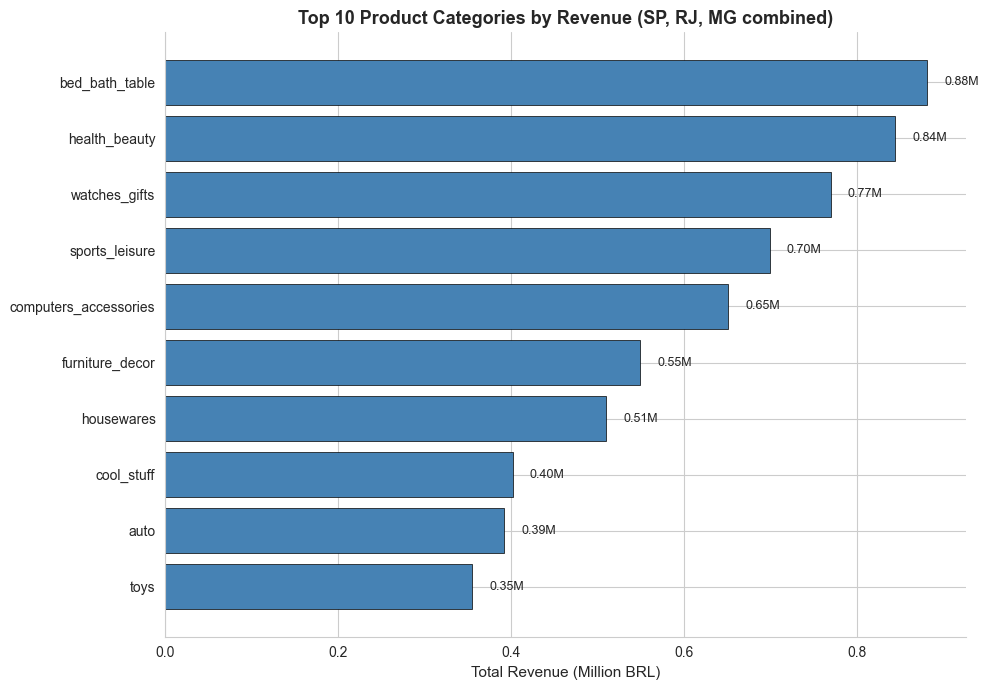

In [34]:
top_10_categories = category_revenue.head(10)

# Horizontal bar chart reads better for long category names
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top_10_categories['product_category_name_english'][::-1],  # reverse for top-down ordering
    top_10_categories['total_revenue'][::-1] / 1_000_000,
    color='steelblue', edgecolor='black', linewidth=0.5
)

ax.set_xlabel('Total Revenue (Million BRL)', fontsize=11)
ax.set_title('Top 10 Product Categories by Revenue (SP, RJ, MG combined)', 
             fontsize=13, fontweight='bold')

# Value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.02, bar.get_y() + bar.get_height()/2,
            f'{width:.2f}M', ha='left', va='center', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Findings: Category breakdown within top states

**Category revenue is more evenly distributed than state revenue.** 
Across SP, RJ, and MG, the top 10 categories range from BRL 880K (bed_bath_table) 
down to BRL 354K (toys), a span of only 2.5x between #1 and #10. This stands in 
contrast to the state-level concentration where São Paulo alone was 18x larger 
than the smallest top 10 state. Customers in major markets buy broadly across 
many categories, suggesting Olist functions as a general marketplace rather 
than a category specialist.

**The product mix skews toward home, lifestyle, and self-care.** 
Bed_bath_table, furniture_decor, housewares, and health_beauty together 
account for over BRL 2.3M in revenue across the top three states. Categories 
typically dominant on general marketplaces, particularly electronics, 
books, and fashion, appear smaller here. This could reflect either 
Olist's market positioning as a lifestyle-oriented marketplace, or untapped 
demand in categories where Olist has weaker brand presence.

**Volume vs. value patterns differ by category.** 
Bed_bath_table moves the highest item volume, with 8,084 items generating 
BRL 880K, or roughly BRL 109 per item. Health_beauty achieves nearly the same 
revenue (BRL 844K) with 23% fewer items, implying a higher per-item value 
at BRL 136. Watches_gifts shows the strongest value pattern, with BRL 769K from 
just 3,706 items, or BRL 207 per item. These differences suggest categories 
require distinct operational strategies: high-volume categories depend on 
fulfillment efficiency, while high-value categories depend more on trust 
and returns handling.

**Business implication.** 
Two strategic options follow from this analysis. First, Olist could 
**double down on its current category strengths**: prioritize seller 
acquisition in home goods, lifestyle products, and personal care, feature 
these categories prominently in marketing, and build category-specific 
tools for sellers in this space. Second, Olist could **diversify into 
underrepresented categories** such as electronics, books, and fashion by 
partnering with established sellers or running targeted promotions to test 
latent demand. The current data suggests the first path aligns with revealed 
customer preference, but the second could expand the total addressable market.

### Caveats
- Analysis covers SP, RJ, and MG only (top 3 revenue states).
- 1,559 items had no English category translation and were excluded.
- "Item revenue" includes both price and freight; per-unit profitability is 
not assessed.
- Volume vs. value patterns are observed but not explained; differences may 
reflect category economics, seller mix on the platform, or pricing strategy.
- This analysis does not segment by customer demographics or purchase recency.

## 5. Question 2: Delivery time and customer reviews

Does faster delivery correlate with better review scores? This analysis 
computes actual delivery time (purchase to customer delivery) for completed 
orders, examines its distribution, and tests whether delivery speed predicts 
review scores.

In [35]:
# Build a clean order-level dataframe for delivery analysis
# Only delivered orders have complete date information

orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# Compute delivery time in days
orders_delivered['delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] - 
    orders_delivered['order_purchase_timestamp']
).dt.days

# Compute estimated delivery time for comparison
orders_delivered['estimated_days'] = (
    orders_delivered['order_estimated_delivery_date'] - 
    orders_delivered['order_purchase_timestamp']
).dt.days

# How much earlier (positive) or later (negative) than estimate?
orders_delivered['delivery_vs_estimate'] = (
    orders_delivered['estimated_days'] - orders_delivered['delivery_days']
)

print("Orders with delivery info:", orders_delivered.shape)
print("\nDelivery days summary:")
print(orders_delivered['delivery_days'].describe())

Orders with delivery info: (96478, 11)

Delivery days summary:
count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64


In [36]:
# Sanity check: are there impossible values?
print("Negative delivery days (impossible):", (orders_delivered['delivery_days'] < 0).sum())
print("Null delivery days (missing delivery date):", orders_delivered['delivery_days'].isnull().sum())
print("Delivery > 100 days (suspicious):", (orders_delivered['delivery_days'] > 100).sum())

# Show a few of the extreme cases
print("\nLongest deliveries:")
print(orders_delivered.nlargest(5, 'delivery_days')[
    ['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'delivery_days']
])

Negative delivery days (impossible): 0
Null delivery days (missing delivery date): 8
Delivery > 100 days (suspicious): 63

Longest deliveries:
                               order_id order_purchase_timestamp  \
19590  ca07593549f1816d26a572e06dc1eab6      2017-02-21 23:31:27   
55619  1b3190b2dfa9d789e1f14c05b647a14a      2018-02-23 14:57:35   
61610  440d0d17af552815d15a9e41abe49359      2017-03-07 23:59:51   
38509  0f4519c5f1c541ddec9f21b3bddd533a      2017-03-09 13:26:57   
70307  2fb597c2f772eca01b1f5c561bf6cc7b      2017-03-08 18:09:02   

      order_delivered_customer_date  delivery_days  
19590           2017-09-19 14:36:39          209.0  
55619           2018-09-19 23:24:07          208.0  
61610           2017-09-19 15:12:50          195.0  
38509           2017-09-19 14:38:21          194.0  
70307           2017-09-19 14:33:17          194.0  


In [37]:
# Filter to plausible delivery times
delivery_clean = orders_delivered[
    (orders_delivered['delivery_days'] >= 0) & 
    (orders_delivered['delivery_days'].notnull())
].copy()

# For visualization purposes, also compute a "main range" filter
delivery_main = delivery_clean[delivery_clean['delivery_days'] <= 60].copy()

print("After cleaning (0+ days, not null):", delivery_clean.shape)
print("After capping at 60 days (main range):", delivery_main.shape)
print("Lost to extreme outliers (>60 days):", len(delivery_clean) - len(delivery_main))

After cleaning (0+ days, not null): (96470, 11)
After capping at 60 days (main range): (96182, 11)
Lost to extreme outliers (>60 days): 288


### Distribution of delivery times

The distribution of delivery times is right-skewed: most orders arrive 
within a few weeks, with a long tail of unusually slow deliveries.

*Note: the histogram below uses a 60-day cap for visual readability 
(288 outliers excluded). The bucketed review analysis later in the 
notebook uses the full unfiltered data, including a 60+ days bucket.*

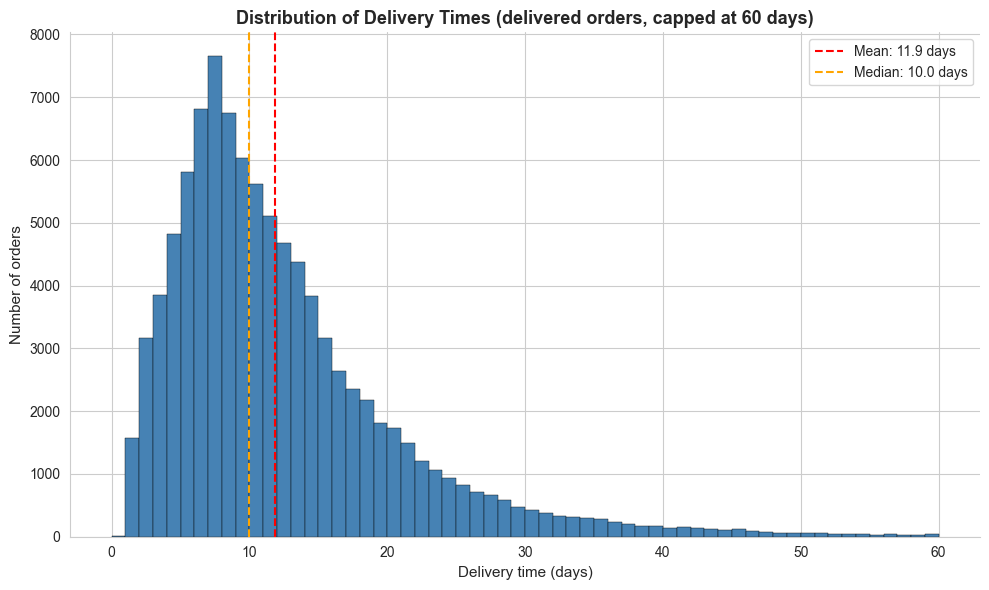

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(delivery_main['delivery_days'], bins=60, color='steelblue', edgecolor='black', linewidth=0.3)

ax.axvline(delivery_main['delivery_days'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {delivery_main['delivery_days'].mean():.1f} days")
ax.axvline(delivery_main['delivery_days'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: {delivery_main['delivery_days'].median():.1f} days")

ax.set_xlabel('Delivery time (days)', fontsize=11)
ax.set_ylabel('Number of orders', fontsize=11)
ax.set_title('Distribution of Delivery Times (delivered orders, capped at 60 days)', fontsize=13, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Key observations from the distribution:**
- Median delivery time: 10.0 days
- Mean delivery time: 11.9, slightly higher than median due to right skew
- The right skew indicates a small number of orders take notably longer than 
typical, pulling the mean upward.
- This baseline matters: if customers expect about 10 days and receive their order 
in 8, that's a positive experience. If they wait 40+ days, that's a negative 
experience even if the platform's average is acceptable.

### Joining reviews to delivery data

Each order has an associated review score (1-5). We join the reviews dataset 
to our cleaned delivery dataframe to enable analysis of how delivery time 
relates to customer satisfaction.

In [39]:
print(reviews.shape)
print(reviews.columns.tolist())
reviews.head()

(99224, 7)
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [40]:
print("Total reviews:", len(reviews))
print("Unique orders in reviews:", reviews['order_id'].nunique())
print("Difference (duplicates):", len(reviews) - reviews['order_id'].nunique())

Total reviews: 99224
Unique orders in reviews: 98673
Difference (duplicates): 551


In [41]:
# Take the latest review per order (in case of duplicates)
reviews_clean = reviews.sort_values('review_creation_date').drop_duplicates(
    subset='order_id', keep='last'
)[['order_id', 'review_score']]

print("Reviews after dedup:", len(reviews_clean))

# Join to our cleaned delivery data
delivery_reviews = delivery_clean.merge(reviews_clean, on='order_id', how='inner')

print("Orders with both delivery time AND review:", len(delivery_reviews))
print("Lost (orders without reviews):", len(delivery_clean) - len(delivery_reviews))

Reviews after dedup: 98673
Orders with both delivery time AND review: 95824
Lost (orders without reviews): 646


### Average review score by delivery time bucket

Since review scores are integers (1-5), we group orders into delivery time 
buckets and compute the average review for each bucket. This reveals 
whether faster delivery correlates with higher satisfaction.

In [42]:
# Create delivery time buckets that match customer experience
bins = [0, 7, 14, 21, 30, 60, float('inf')]
labels = ['0-7 days', '8-14 days', '15-21 days', '22-30 days', '31-60 days', '60+ days']

delivery_reviews['delivery_bucket'] = pd.cut(
    delivery_reviews['delivery_days'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# Aggregate review score by bucket
bucket_analysis = delivery_reviews.groupby('delivery_bucket', observed=True).agg(
    avg_review=('review_score', 'mean'),
    median_review=('review_score', 'median'),
    n_orders=('review_score', 'count'),
    pct_5_star=('review_score', lambda x: (x == 5).mean() * 100),
    pct_1_star=('review_score', lambda x: (x == 1).mean() * 100)
).reset_index()

bucket_analysis

,delivery_bucket,avg_review,median_review,n_orders,pct_5_star,pct_1_star
0,0-7 days,4.408599,5.0,33539,67.879185,5.396702
1,8-14 days,4.288477,5.0,36190,62.111080,6.769826
2,15-21 days,4.101612,5.0,15264,54.238732,9.008124
3,22-30 days,3.494431,4.0,6824,38.232708,21.101993
4,31-60 days,2.174076,1.0,3734,15.158007,56.614890
5,60+ days,2.175824,1.0,273,16.117216,59.706960


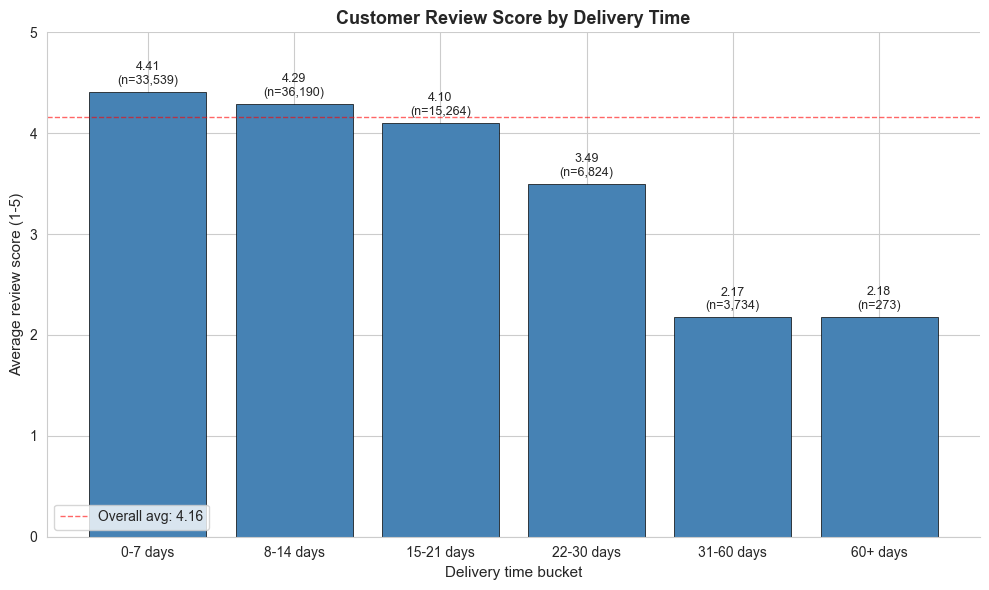

In [43]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart of average review score
bars = ax1.bar(
    bucket_analysis['delivery_bucket'].astype(str),
    bucket_analysis['avg_review'],
    color='steelblue', edgecolor='black', linewidth=0.5
)

ax1.set_xlabel('Delivery time bucket', fontsize=11)
ax1.set_ylabel('Average review score (1-5)', fontsize=11)
ax1.set_title('Customer Review Score by Delivery Time', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 5)

# Value labels on top of bars
for bar, n in zip(bars, bucket_analysis['n_orders']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.05,
             f'{height:.2f}\n(n={n:,})', ha='center', va='bottom', fontsize=9)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.axhline(y=delivery_reviews['review_score'].mean(), color='red', 
            linestyle='--', linewidth=1, alpha=0.6, 
            label=f'Overall avg: {delivery_reviews["review_score"].mean():.2f}')
ax1.legend(loc='lower left')

plt.tight_layout()
plt.show()

In [44]:
# Pearson correlation (linear)
from scipy.stats import pearsonr, spearmanr

# Linear correlation
pearson_corr, pearson_p = pearsonr(
    delivery_reviews['delivery_days'], 
    delivery_reviews['review_score']
)

# Rank correlation (better for non-linear monotonic relationships)
spearman_corr, spearman_p = spearmanr(
    delivery_reviews['delivery_days'], 
    delivery_reviews['review_score']
)

print(f"Pearson correlation:  {pearson_corr:.3f}  (linear)")
print(f"Spearman correlation: {spearman_corr:.3f}  (rank-based)")
print(f"\nSample size: {len(delivery_reviews):,} orders")

Pearson correlation:  -0.334  (linear)
Spearman correlation: -0.235  (rank-based)

Sample size: 95,824 orders


### Findings: Delivery time and customer reviews

**Delivery time is a significant driver of customer satisfaction.** 
The Pearson correlation between delivery time and review score is -0.334 
across 95,824 orders, with average reviews falling from 4.41 in the 0-7 day 
bucket to 2.17 in the 31-60 day bucket, a drop of more than 2 points on a 
5-point scale. The relationship is both statistically robust (n=95,824) and 
operationally meaningful.

**Customer satisfaction has a sharp threshold at roughly 21-30 days.** 
The relationship is not gradual; it is a cliff. Average reviews stay above 
4.0 up to 21 days; in the 22-30 day bucket they drop to 3.49 and the 1-star 
rate jumps from 9% to 21%. Beyond 30 days, 1-star reviews become the 
majority: 56% of customers in the 31-60 day bucket leave the worst 
possible review. Once deliveries cross 30 days, additional delay does not 
further reduce satisfaction; the damage is already done.

**Business implication.** Olist should focus operational investment on 
keeping deliveries under 21 days, not on improving from "very late" to 
"moderately late." Each day saved in the 21-30 day range delivers more 
satisfaction gain than the same day saved in the 0-14 day range. Once a 
delivery exceeds 30 days, downstream recovery does not restore the 
customer; prevention is the only effective lever. This suggests 
prioritization should focus on identifying orders at risk of slipping past 
the 21-day threshold and intervening early, for example by flagging 
slow-moving shipments at day 10 for proactive follow-up.

### Caveats

- Correlation does not imply causation; slow deliveries may be associated 
with other underlying issues (poor seller communication, low product 
quality, packaging problems) that independently affect reviews.
- Reviews are influenced by many factors beyond delivery time, including 
product quality, customer expectations, and seller responsiveness.
- The 60+ days bucket has a small sample (n=273) and should be interpreted 
with caution.
- Some 1-star reviews may concern issues unrelated to delivery time (defective 
items, incorrect orders).
- This is observational analysis; a causal claim would require experimental 
evidence (e.g., A/B testing expedited shipping against standard delivery).

## 6. Conclusions and recommendations

### Combined findings

This analysis surfaced two patterns that, taken together, point to a clear 
operational picture for Olist:

1. **Where the business lives.** Revenue is concentrated in São Paulo, Rio de 
   Janeiro, and Minas Gerais, which together account for roughly 77% of top 10 
   revenue. São Paulo alone generates BRL 5.77M. Category mix within these markets 
   is broad rather than specialist, but skews toward home, lifestyle, and 
   self-care (bed_bath_table, health_beauty, furniture_decor, housewares).

2. **What hurts customers.** Delivery time is a strong, statistically robust 
   predictor of review scores (Pearson r = -0.334, n = 95,824). The 
   relationship is not gradual; it is a cliff at 21-30 days. Once a 
   delivery passes 30 days, the customer is functionally lost: 56% leave 
   1-star reviews.

### Recommendations

- **Protect the 21-day threshold.** Build an early-warning flag for shipments 
  that have not moved past a defined milestone by day 10. The marginal 
  satisfaction gain from preventing a 21-to-25 day slip is larger than from 
  improving a 10-to-8 day delivery.
- **Weight operational investment toward the volume markets** (São Paulo, Rio 
  de Janeiro, Minas Gerais). These markets are where any logistics improvement 
  compounds across the most orders.
- **Test basket-size strategies in higher-AOV smaller states.** Bahia, Goiás, 
  and Santa Catarina already show larger basket sizes; targeted upsell or 
  bundling tests there are likely to outperform the same tests in São Paulo.
- **Decide deliberately on category strategy.** The current mix is 
  lifestyle-skewed. Either lean into that (seller acquisition, marketing) 
  or actively diversify into electronics, fashion, and books, but don't drift.

### What I would do with more time

- **Causal analysis on delivery and reviews.** The current finding is 
  correlational. Slow deliveries probably co-occur with other quality issues 
  (poor seller communication, packaging problems) that independently drag reviews. 
  Disentangling these would require either text analysis of review comments 
  or a quasi-experimental design.
- **Seller-level segmentation.** Which sellers are responsible for the 
  long delivery tail? A small number of underperforming sellers may explain 
  a disproportionate share of bad reviews.
- **Time-series view.** Did delivery performance and revenue concentration 
  change over the 2016-2018 data window? A trend analysis would tell us 
  whether the patterns are stable or evolving.
- **Geographic granularity.** State-level is coarse. City- or zip-level 
  revenue and delivery analysis would surface whether São Paulo's dominance is 
  metro-driven or spread across the state.
- **SQL re-implementation.** Re-running the same analyses in SQL against 
  the same data loaded into SQLite would demonstrate fluency in both 
  languages and is on my list for the next iteration.